In [6]:

import numpy as np
import pandas as pd 



In [7]:
df =  pd.read_csv('Churn_Modelling.csv')

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
print(df.shape)

(10000, 14)


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [13]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [14]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [15]:
df.drop(columns = ["RowNumber","CustomerId","Surname"],inplace=True)

In [16]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df_encoded = pd.get_dummies(
    df,
    columns=['Gender', 'Geography'],
    dtype=int,drop_first = True
)

In [18]:
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [19]:
X = df_encoded.drop(columns = "Exited")
y = df_encoded["Exited"]

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.2, random_state =  1)

In [22]:
X_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain
9953,550,47,2,0.00,2,1,1,97057.28,1,0,0
3850,680,34,3,143292.95,1,1,0,66526.01,1,0,0
4962,531,42,2,0.00,2,0,1,90537.47,0,0,0
3886,710,34,8,147833.30,2,0,1,1561.58,1,1,0
5437,543,30,6,73481.05,1,1,1,176692.65,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
3919,763,39,7,0.00,2,1,0,19458.75,0,0,1
162,800,49,7,108007.36,1,0,0,47125.11,0,0,0
7903,567,34,10,0.00,2,0,1,161571.79,1,0,1
2242,621,30,2,101014.08,2,1,1,165257.31,0,1,0


In [23]:
from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
import tensorflow
from tensorflow import keras

In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [27]:
model = Sequential()
model.add(Dense(11,activation = 'relu',input_dim = 11))
model.add(Dense(11,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))


g:\Deep learning\customerchunkpred\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(loss = "binary_crossentropy",optimizer = "Adam",metrics = ["accuracy"])


In [30]:
history = model.fit(X_train_scaled,y_train,epochs = 100,validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7197 - loss: 0.5703 - val_accuracy: 0.8000 - val_loss: 0.4882
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8012 - loss: 0.4664 - val_accuracy: 0.8031 - val_loss: 0.4530
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8083 - loss: 0.4368 - val_accuracy: 0.8062 - val_loss: 0.4346
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.4202 - val_accuracy: 0.8175 - val_loss: 0.4195
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8244 - loss: 0.4058 - val_accuracy: 0.8231 - val_loss: 0.4062
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8338 - loss: 0.3933 - val_accuracy: 0.8356 - val_loss: 0.3904
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8423 - loss: 0.3813 - val_accuracy: 0.8381 - val_loss: 0.3779
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8487 - loss: 0.3712 - val_accu

In [31]:
model.layers[1].get_weights()

[array([[-0.6946044 ,  0.6146189 , -0.35568815, -0.41179162,  0.01641079,
         -0.2567557 , -0.27228916, -0.6259456 ,  0.88575673,  0.10573643,
         -0.40507   ],
        [ 0.56013715, -0.08661384, -0.5599936 ,  0.8164453 , -0.571364  ,
          0.03660884,  0.76678663,  0.6051049 ,  0.39526728,  0.2491851 ,
         -0.2168711 ],
        [-0.27193925,  0.42461315,  0.64956075,  0.44781753,  0.08102107,
         -0.11921764, -0.6535006 ,  0.15217485,  0.11874374, -0.09883733,
          0.25917664],
        [ 0.0982077 ,  0.49211666,  0.60724854, -0.21094352, -1.1231327 ,
          0.3117406 ,  0.02011991,  0.09712917, -0.8119551 ,  0.25576493,
          0.05771818],
        [ 0.23450533,  0.18876778,  0.32529765,  0.03431064, -0.05762761,
         -0.06702862,  0.08895863, -0.0381121 ,  0.48307362,  0.06336088,
          0.43919116],
        [ 0.5272079 ,  0.17438442, -0.913004  , -0.28887835,  0.5822845 ,
          0.5696703 ,  0.5422259 , -0.15701307, -0.6409159 ,  0.0759177

In [32]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [33]:
y_pred = np.where(y_log>0.5,1,0)


In [87]:
from sklearn.metrics import accuracy_score

In [103]:
accuracy_score(y_test,y_pred)

0.8645

In [34]:
import matplotlib.pyplot as plt

In [35]:
history.history

{'accuracy': [0.7196875214576721,
  0.8012499809265137,
  0.8082812428474426,
  0.8151562213897705,
  0.8243749737739563,
  0.8337500095367432,
  0.8423437476158142,
  0.8487499952316284,
  0.8525000214576721,
  0.85546875,
  0.8571875095367432,
  0.8557812571525574,
  0.8576562404632568,
  0.8584374785423279,
  0.8559374809265137,
  0.8556249737739563,
  0.8557812571525574,
  0.8573437333106995,
  0.8565624952316284,
  0.8578125238418579,
  0.8609374761581421,
  0.8578125238418579,
  0.8598437309265137,
  0.860156238079071,
  0.8578125238418579,
  0.8618749976158142,
  0.8623437285423279,
  0.8615624904632568,
  0.8621875047683716,
  0.8623437285423279,
  0.8623437285423279,
  0.8614062666893005,
  0.8635937571525574,
  0.8642187714576721,
  0.8639062643051147,
  0.8634374737739563,
  0.8650000095367432,
  0.8642187714576721,
  0.8637499809265137,
  0.8642187714576721,
  0.8645312786102295,
  0.8653125166893005,
  0.8648437261581421,
  0.8662499785423279,
  0.8667187690734863,
  0.865

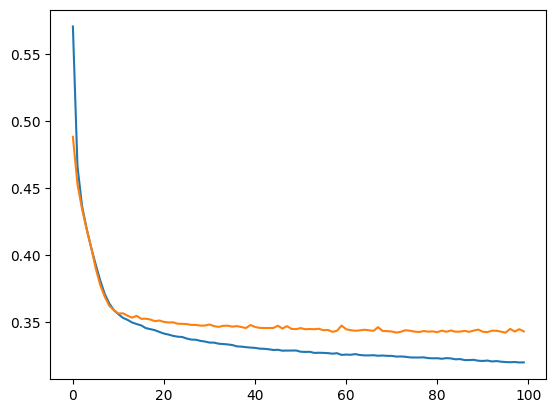

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

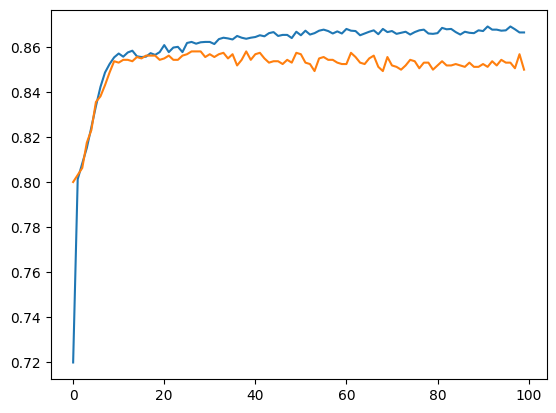

In [37]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])